# Production pipeline demo

Runs `midog_utils.production.run_production_pipeline` end to end on real ROIs: one
clicked annotation in, ranked candidate detections on that ROI out.

Wires DECISIONS.md D1 (`TM_CCOEFF`), D3 (unclipped `hematoxylin_od`), D7 (NMS radius =
`evaluate.radius_px(mpp)`), D8 (`seed_selection.build_seed`'s gated/recentred template)
and D9 (`max_peaks=100`). `rank_key` switches the ranking axis between `tm_score`
(default, D5's production ranker) and `chromatin_od` (opt-in -- D5 bars it from becoming
the default without further validation, not from existing as a selectable axis).

This is a wiring/visualization demo, not a new measurement.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from midog_utils import dataset as ds
from midog_utils import channels as ch
from midog_utils import evaluate as ev
from midog_utils import seed_selection as ss
from midog_utils import viz
from midog_utils import production as prod

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)

In [2]:
IMAGES_DIR = '../images/extra_valid'
ROIS = ['245.tiff', '403.tiff']   # the two ROIs pipeline_debug_visuals/ already uses to
                                  # exercise the seed gate: inert on 245, live on 403
SEED_INDEX = 0
RANK_KEYS = ('tm_score', 'chromatin_od')
DOWNSAMPLE = 4                    # viz.overlay's own default; shared here so draw_box matches

images, annotations = ds.load_annotations('../databases/MIDOG++.json')
meta_ix = images.set_index('file_name')[['image_id', 'tumor_type']]

In [3]:
def run_one(fn):
    """One ROI: draw a D8-gated seed, run the production pipeline on both rank_keys."""
    path = f'{IMAGES_DIR}/{fn}'
    image_id = int(meta_ix.loc[fn, 'image_id'])
    rgb = ds.load_roi(path)
    mpp = ds.roi_mpp(path)
    roi_shape = rgb.shape
    match_radius = ev.radius_px(mpp)
    gray_inv = ch.to_channel(rgb, 'gray_inverted')

    gt = ds.image_annotations(annotations, fn)
    gt_mitotic = gt[gt['category_id'] == ds.MITOTIC]
    rng = np.random.default_rng([SEED_INDEX, image_id])
    seed = ss.build_seed(gt_mitotic, gray_inv, rng, roi_shape)  # D8 production, zero overrides

    # Ground truth stays keyed to the click; only the template moved (D8 item 3).
    gt_eval = gt[gt['ann_id'] != seed.ann_id].reset_index(drop=True)

    results = {}
    for rank_key in RANK_KEYS:
        det, info = prod.run_production_pipeline(rgb, seed, mpp, rank_key=rank_key)
        # Bucketed separately per axis -- greedy-match order depends on rank order, so
        # sharing one axis's buckets with the other would silently misscore it.
        det_out, gt_out = ev.bucket_detections(det, gt_eval, match_radius)
        results[rank_key] = dict(det=det_out, gt=gt_out, info=info)

    return dict(rgb=rgb, mpp=mpp, seed=seed, gt_eval=gt_eval, match_radius=match_radius,
                results=results)


ROI_DATA = {fn: run_one(fn) for fn in ROIS}
for fn, d in ROI_DATA.items():
    s = d['seed']
    print(f"{fn}: seed ann {s.ann_id}, base_size {s.base_size}, "
          f"click-to-template offset {s.offset_px:.2f}px, n_retries {s.n_retries}")

245.tiff: seed ann 6274, base_size 47, click-to-template offset 3.61px, n_retries 0
403.tiff: seed ann 20356, base_size 51, click-to-template offset 2.00px, n_retries 1


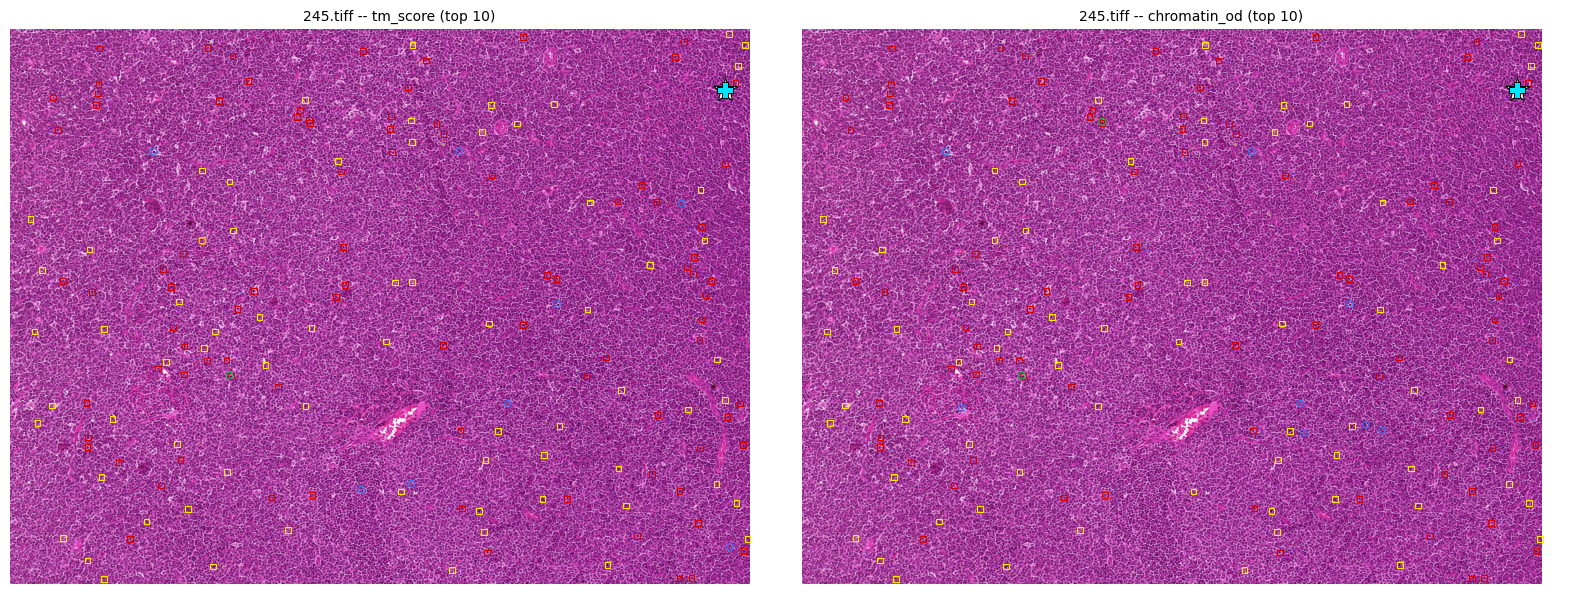

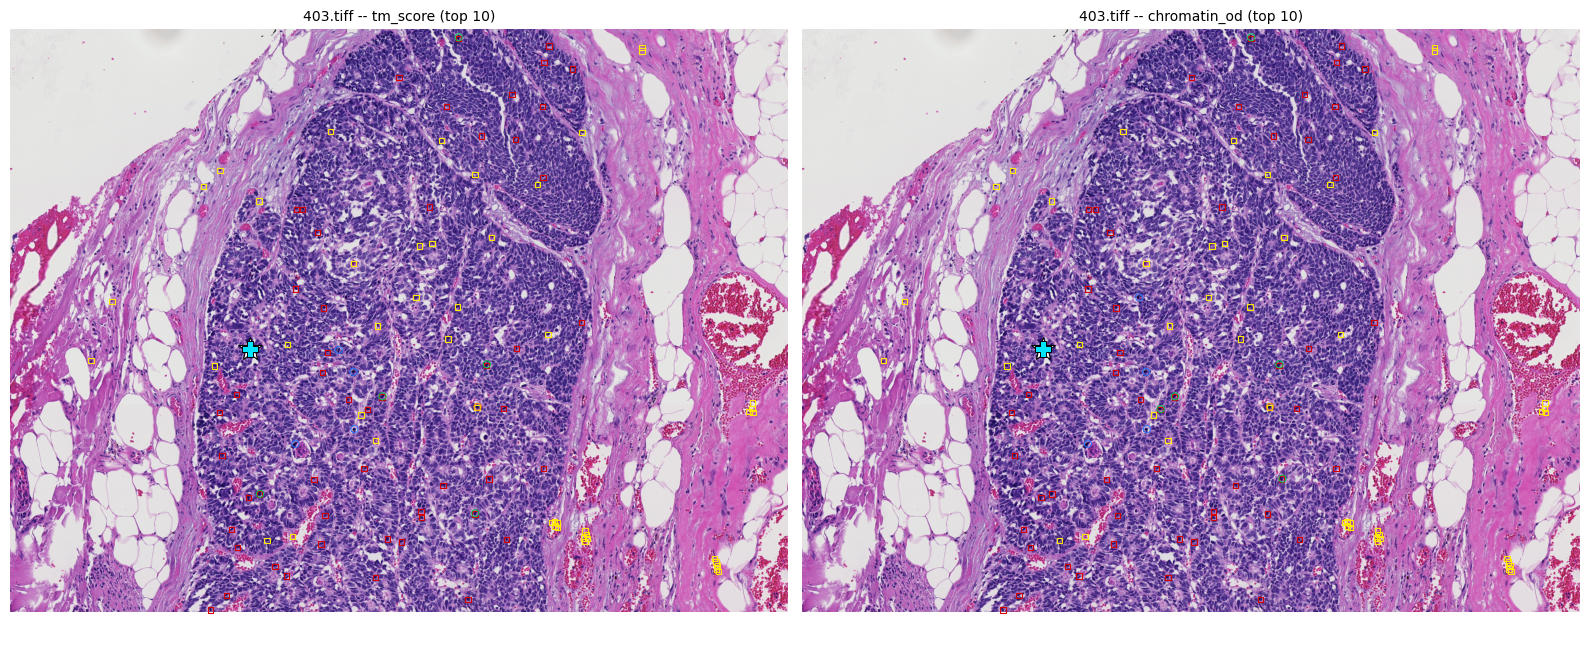

In [4]:
for fn, d in ROI_DATA.items():
    seed = d['seed']
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    for ax, rank_key in zip(axes, RANK_KEYS):
        r = d['results'][rank_key]
        viz.overlay(d['rgb'], d['gt_eval'], r['det'], seed_xy=seed.click_xy,
                   tpl_xy=seed.template_xy, ax=ax, downsample=DOWNSAMPLE, top_n=10,
                   radius=d['match_radius'], title=f'{fn} -- {rank_key} (top 10)')

        # The base_size square at the D8 template centre -- the search's own footprint.
        # base_size is always odd (template_match._odd), so this box's pixel centre is
        # exactly seed.template_xy, matching seed_selection.tightened_template_box's own
        # half-pixel-correct convention.
        half = (seed.base_size - 1) // 2
        tx, ty = seed.template_xy
        box = (ty - half, ty - half + seed.base_size, tx - half, tx - half + seed.base_size)
        viz.draw_box(ax, box, '#00e5ff', lw=1.2, scale=1.0 / DOWNSAMPLE)
    fig.tight_layout()
    plt.show()

In [5]:
rows = []
for fn, d in ROI_DATA.items():
    n_gt = int((d['gt_eval']['category_id'] == ds.MITOTIC).sum())
    for rank_key in RANK_KEYS:
        det, info = d['results'][rank_key]['det'], d['results'][rank_key]['info']
        top10 = det.head(10)
        tp10 = int((top10['bucket'] == ev.HUMAN_CORRECT_LABEL).sum())
        rows.append(dict(
            roi=fn, rank_key=rank_key, n_peaks=info['n_peaks'],
            max_peaks_binding=info['max_peaks_binding'], n_detections=info['n_detections'],
            precision_at_10=round(tp10 / min(10, len(det)), 3) if len(det) else float('nan'),
            recall_at_10=round(tp10 / n_gt, 3) if n_gt else float('nan'),
        ))

summary = pd.DataFrame(rows)
summary

,roi,rank_key,n_peaks,max_peaks_binding,n_detections,precision_at_10,recall_at_10
0,245.tiff,tm_score,100,True,89,0.1,0.011
1,245.tiff,chromatin_od,100,True,89,0.2,0.022
2,403.tiff,tm_score,100,True,98,0.5,0.096
3,403.tiff,chromatin_od,100,True,98,0.5,0.096


## Notes

- `chromatin_od` is shown here purely to demonstrate the ranking knob -- D5 keeps it an
  opt-in second axis, not a promoted default. A 5-seed sweep
  (`threshold_maxpeaks_ablation/chromatin_od_ranker_seed_robustness.ipynb`) found seed 0
  (used above) is not a neutral draw for this comparison: it ranks best-of-5 for
  `tm_score`-vs-`chromatin_od`, so any apparent edge above is not evidence of a general
  advantage.
- `max_peaks=100` (D9) is validated at zero measured precision/recall cost through K=30,
  on a single seed, 14 ROIs -- not tested past K=30, not yet a multi-seed result.